# Explanation sheets — paper code

This notebook reproduces every figure in the paper. The repeated logic
(neighbor finding, SHAP computation, plotting, ICE curves, SHAP regression)
lives in `explanation_helpers.py`, so each figure below is only a few lines.

**Requirements:** `explanation_helpers.py` must sit next to this notebook.

Run the cells top to bottom.

## 1. Load and preprocess data

In [1]:
import kagglehub
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# --------- Load data ---------
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
data = pd.read_csv(Path(path) / "heart_disease_uci.csv")

# --------- Preprocess data ---------
data = data.drop(["id", "dataset"], axis=1)
data.loc[data["chol"] == 0, "chol"] = float("nan")   # treat 0 cholesterol as missing

row_thresh = int(len(data.columns) * 0.3)            # keep rows with >=30% non-NA
data = data.dropna(thresh=row_thresh)

# impute: median for numeric, most frequent for categorical
num_cols = data.select_dtypes(include=["int64", "float64"]).columns
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()
data[num_cols] = SimpleImputer(strategy="median").fit_transform(data[num_cols])
data[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(data[cat_cols])

# encode categorical features as integers; keep the mapping for reference
label_maps = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))

data = data.reset_index(drop=True)   # reset indices after dropped rows

X = data.drop("num", axis=1)
y = (data["num"] > 0).astype(int)    # binarize outcome

## 2. Train models

In [2]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


def train_and_report(model, name):
    model.fit(X_train, y_train)
    print(f"{name:<14} train acc: {accuracy_score(y_train, model.predict(X_train)):.3f}"
          f"   test acc: {accuracy_score(y_test, model.predict(X_test)):.3f}")
    return model


cb = train_and_report(
    CatBoostClassifier(depth=3, iterations=100, verbose=False, random_state=42),
    "CatBoost")
rf = train_and_report(
    RandomForestClassifier(random_state=42),
    "Random Forest")
gam = train_and_report(
    CatBoostClassifier(depth=1, iterations=300, verbose=False, random_state=42),
    "GAM")

CatBoost       train acc: 0.844   test acc: 0.826
Random Forest  train acc: 1.000   test acc: 0.826
GAM            train acc: 0.815   test acc: 0.815


## 3. SHAP values (once per model)

In [3]:
from explanation_helpers import (
    compute_shap_values, find_neighbors, plot_shap_scatter,
    add_shap_regression, add_ice_instance, add_ice_envelope,
)

shap_cb  = compute_shap_values(cb,  X)
shap_rf  = compute_shap_values(rf,  X)
shap_gam = compute_shap_values(gam, X)

SMALL = 12   # font size used for the explanation-card figures

 99%|===================| 1830/1840 [00:36<00:00]        

## 4. Figure 3 — SHAP dependence plot (age)

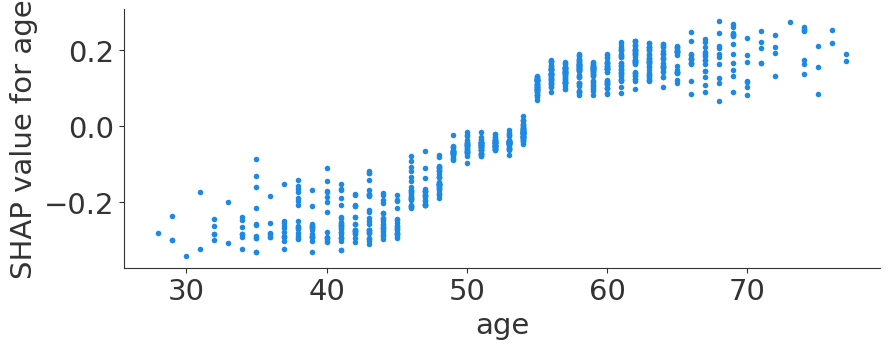

In [62]:
import shap

fig, ax = plt.subplots(figsize=(9, 3.6))
shap.dependence_plot("age", shap_cb, X, ax=ax, interaction_index=None, show=False)
ax.set_xlabel("age", fontsize=21)
ax.set_ylabel("SHAP value for age", fontsize=21)
ax.tick_params(axis="both", labelsize=21)
plt.tight_layout()
plt.show()

## 5. Figure 4 

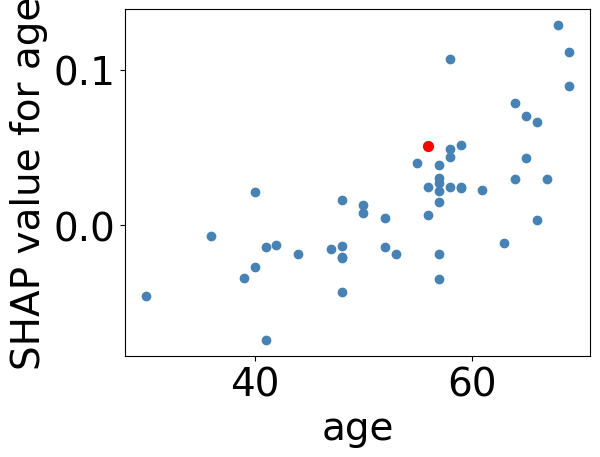

In [29]:
# Figure 4a: Random Forest, plain scatter
nbr = find_neighbors(X, cat_cols, idx_point=12)
fig, ax = plt.subplots(figsize=(6, 4.5))
plot_shap_scatter(ax, X, shap_rf, nbr, 12, "age", fontsize=28);
#ax.legend(fontsize=28)

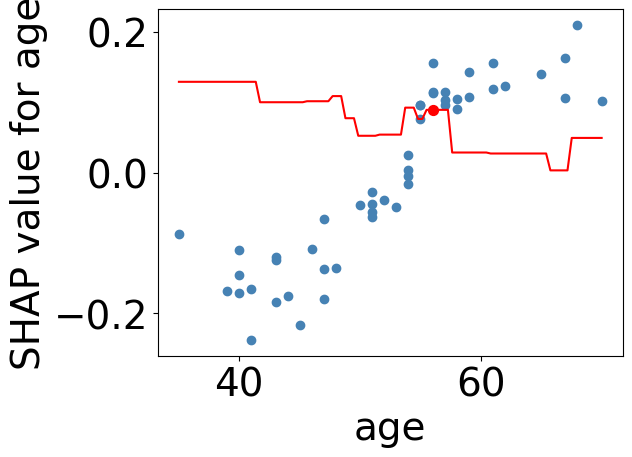

In [30]:
# Figure 4b: CatBoost, scatter + single ICE curve
nbr = find_neighbors(X, cat_cols, idx_point=748)
fig, ax = plt.subplots(figsize=(6, 4.5))
plot_shap_scatter(ax, X, shap_cb, nbr, 748, "age", fontsize=28)
add_ice_instance(ax, cb, X, shap_cb, nbr, 748, "age")
#ax.legend(fontsize=28)

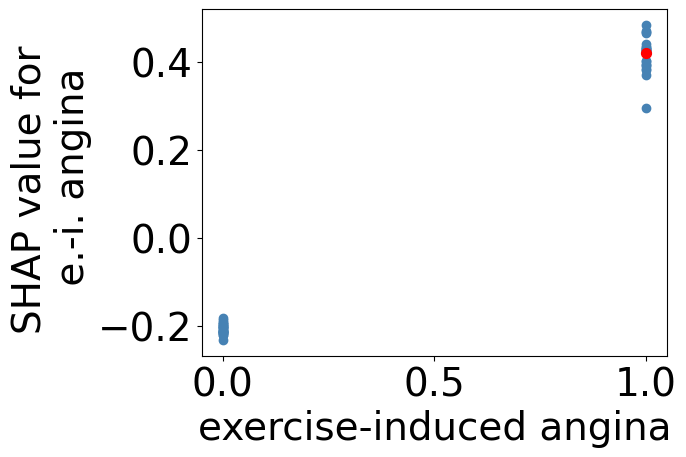

In [31]:
# Figure 4c: CatBoost, categorical feature (exercise-induced angina)
nbr = find_neighbors(X, cat_cols, idx_point=748)
fig, ax = plt.subplots(figsize=(6, 4.5))
plot_shap_scatter(ax, X, shap_cb, nbr, 748, "exang",
                  xlabel="exercise-induced angina",
                  ylabel="SHAP value for \n e.-i. angina",
                  fontsize=28);
#ax.legend(fontsize=28)

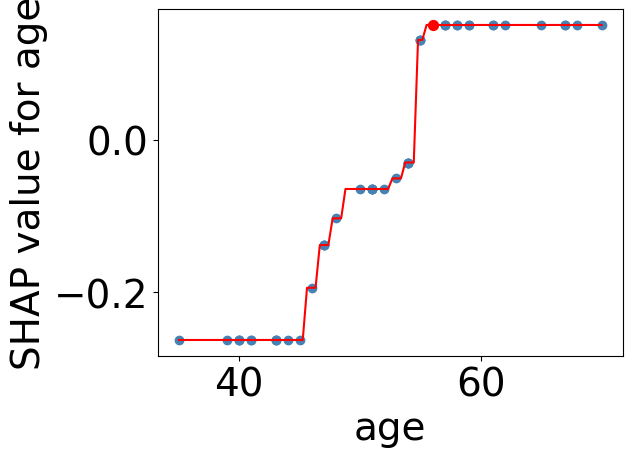

In [32]:
# Figure 4d: GAM, scatter + single ICE curve
nbr = find_neighbors(X, cat_cols, idx_point=748)
fig, ax = plt.subplots(figsize=(6, 4.5))
plot_shap_scatter(ax, X, shap_gam, nbr, 748, "age", fontsize=28)
add_ice_instance(ax, gam, X, shap_gam, nbr, 748, "age")
#ax.legend(fontsize=28)

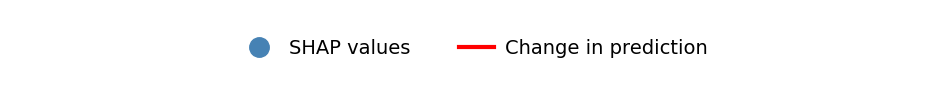

In [66]:
# Legend for Figures 4a-4d
from matplotlib.lines import Line2D

handles = [
    Line2D([], [], linestyle="none", marker="o", color="steelblue",
           markersize=14, label="SHAP values"),
    Line2D([], [], color="red", lw=3, label="Change in prediction"),
]

fig, ax = plt.subplots(figsize=(12, 1))
ax.axis("off")
ax.legend(handles=handles, loc="center", ncol=2, fontsize=14, frameon=False,
          handlelength=1.8, handletextpad=0.6, columnspacing=2.5)
fig.savefig("legend_fig4.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("legend_fig4.png", bbox_inches="tight", pad_inches=0.05,
            dpi=300, transparent=True)

## 6. Figure 6 

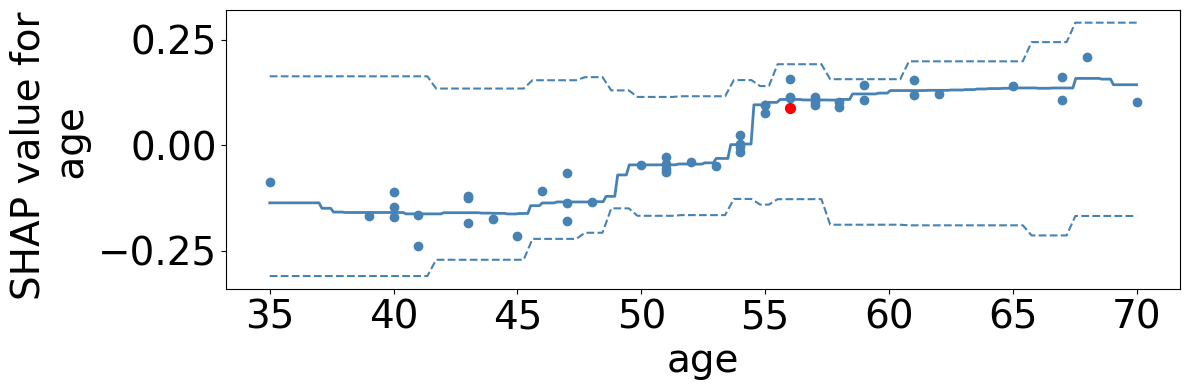

In [64]:
nbr = find_neighbors(X, cat_cols, idx_point=748)
fig, ax = plt.subplots(figsize=(12, 4))
x, y = plot_shap_scatter(ax, X, shap_cb, nbr, 748, "age",
                         ylabel="SHAP value for \n age",
                         fontsize=28)
add_shap_regression(ax, x, y, "age")
add_ice_envelope(ax, cb, X, shap_cb, nbr, "age")
#ax.legend(fontsize=21)
plt.tight_layout()

## 7. Figures 5 & 8 — CatBoost explanation card 

The `age` panel is Figure 5 in the main paper; the remaining panels form the
extended explanation card in the appendix (Figure 8).

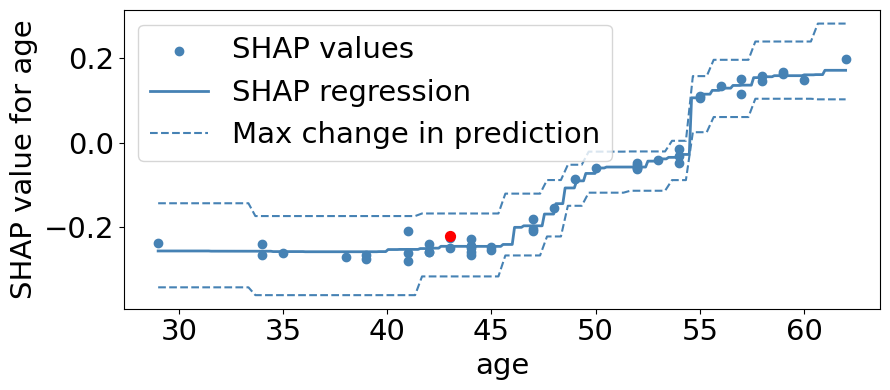

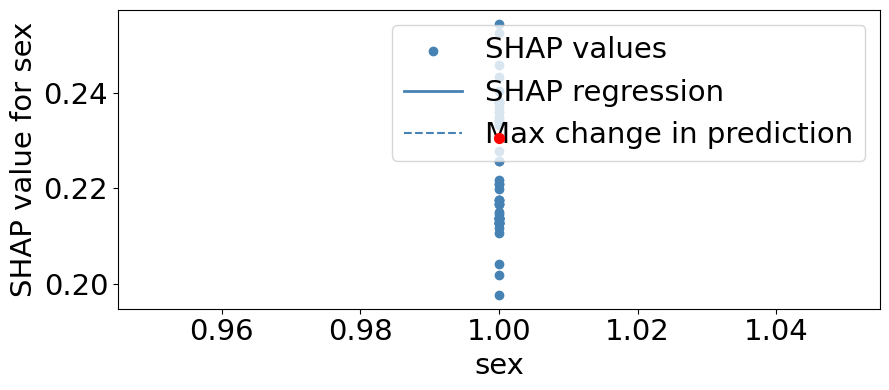

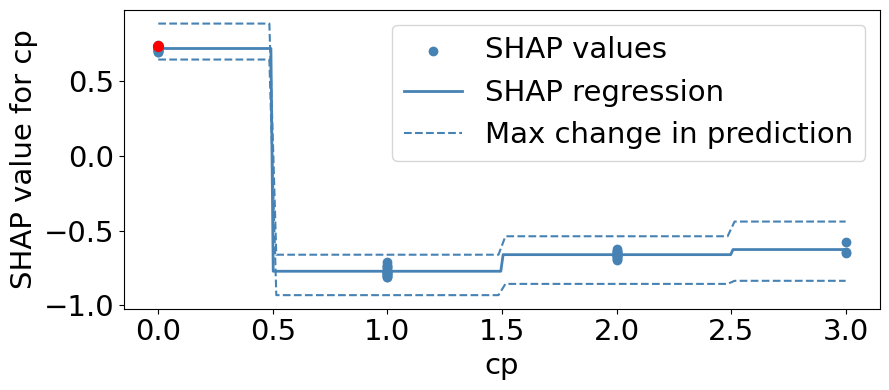

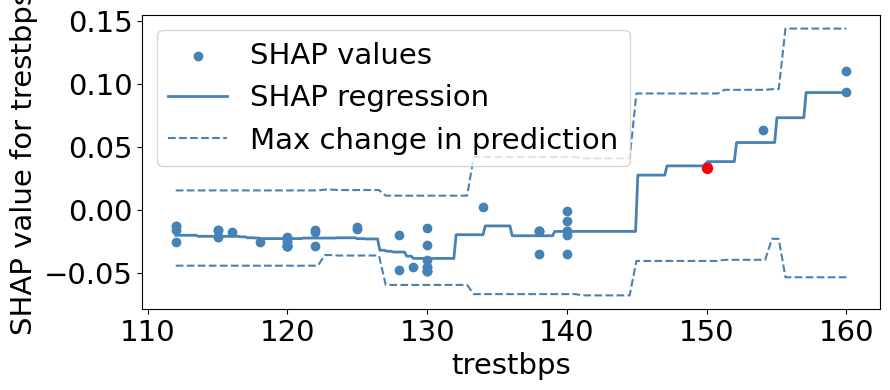

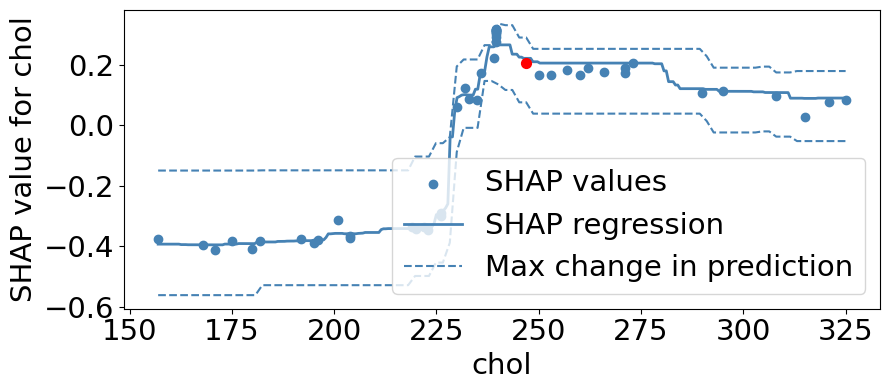

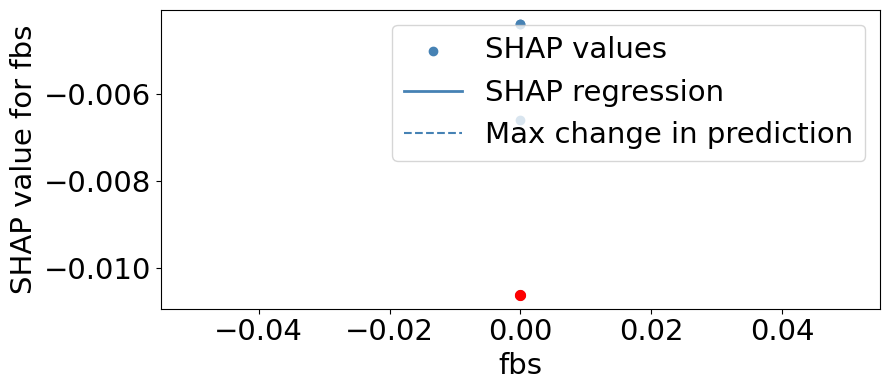

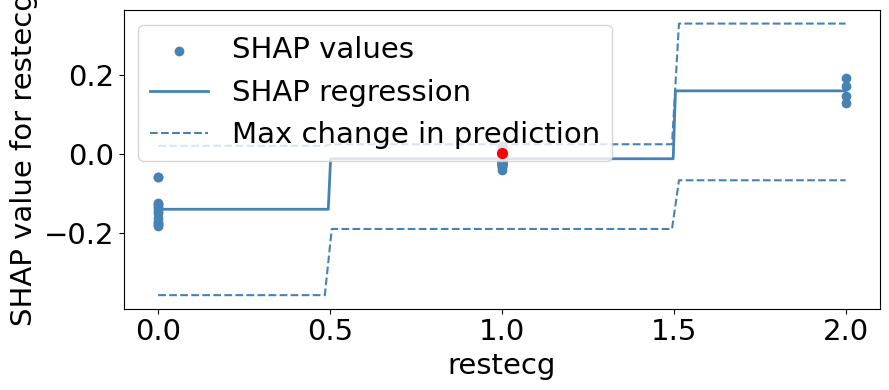

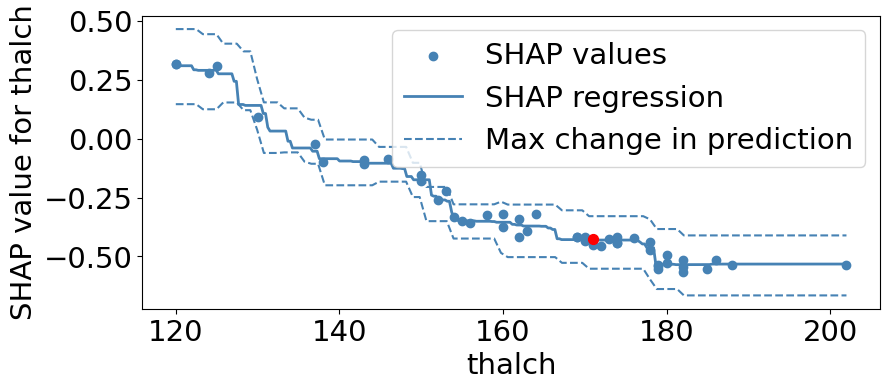

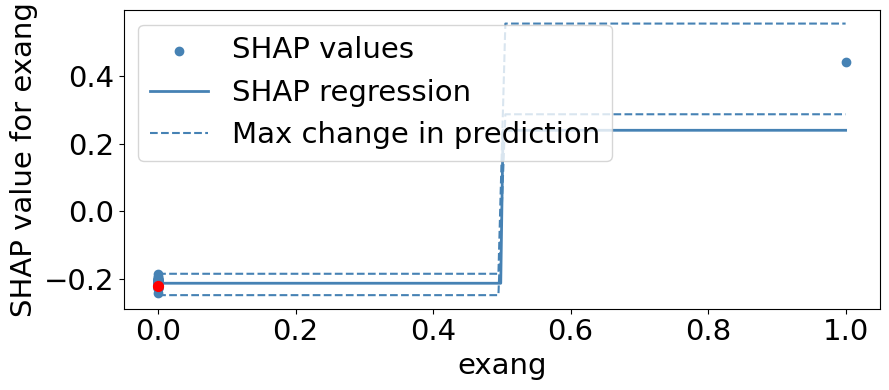

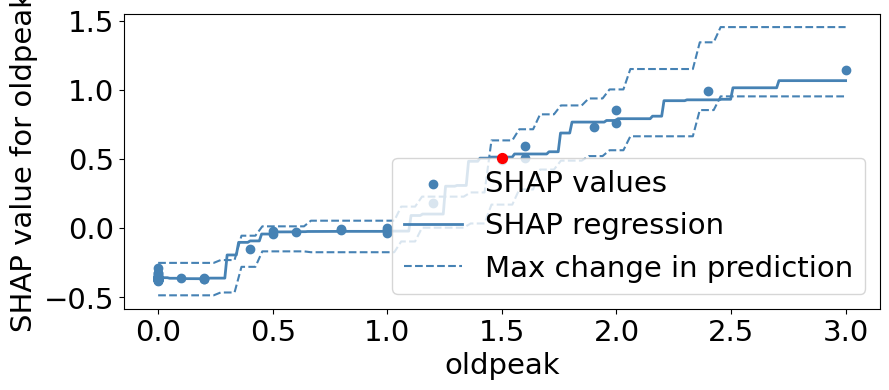

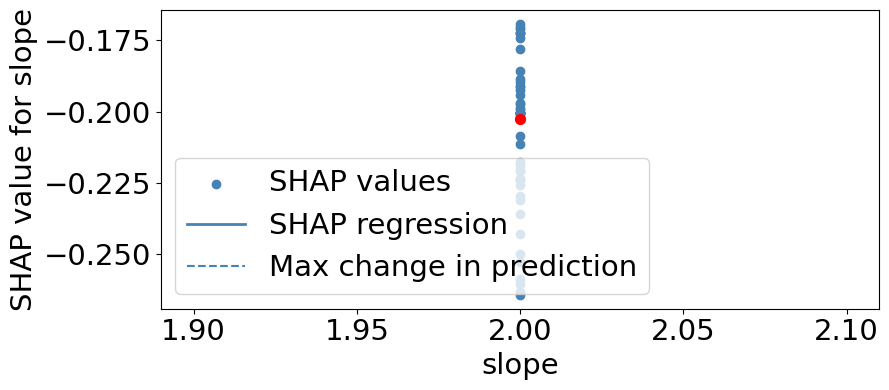

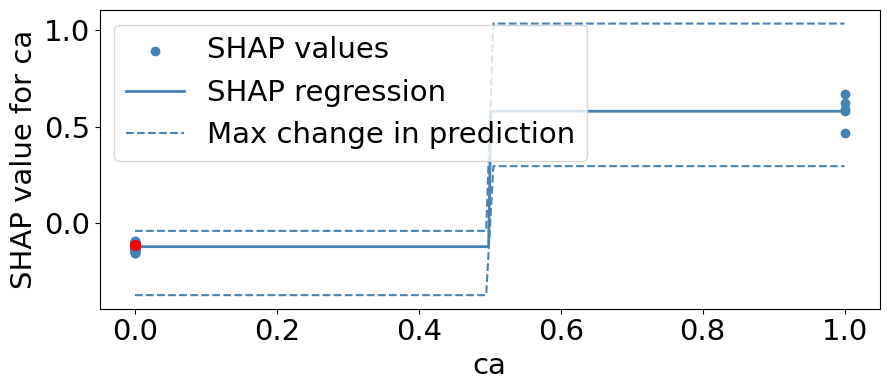

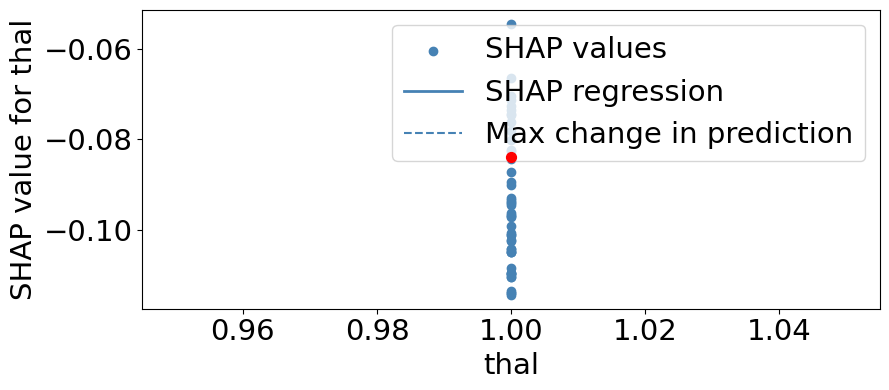

In [42]:
idx_point = 28
nbr = find_neighbors(X, cat_cols, idx_point=idx_point)   # same neighborhood for every panel

for feat in X.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    x, y = plot_shap_scatter(ax, X, shap_cb, nbr, idx_point, feat, fontsize=21,
                             ylabel=f"SHAP value for {feat}")
    add_shap_regression(ax, x, y, feat)
    add_ice_envelope(ax, cb, X, shap_cb, nbr, feat)
    ax.legend(fontsize=21)
    plt.tight_layout()
    plt.savefig(f"SHAP_card_CatBoost_{feat}")

## 8. Figure 9 — Random Forest explanation card (age)

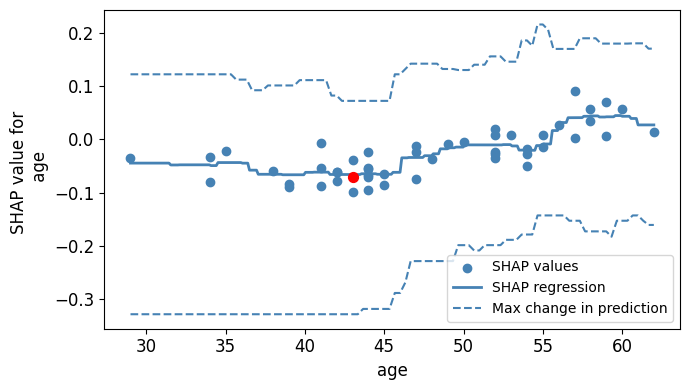

In [11]:
nbr = find_neighbors(X, cat_cols, idx_point=28)
fig, ax = plt.subplots(figsize=(7, 4))
x, y = plot_shap_scatter(ax, X, shap_rf, nbr, 28, "age", fontsize=SMALL,
                         ylabel="SHAP value for \n age")
add_shap_regression(ax, x, y, "age")
add_ice_envelope(ax, rf, X, shap_rf, nbr, "age")
ax.legend()
plt.tight_layout()
plt.savefig("SHAP_card_RandomForestClassifier.png")